In [44]:
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import pingouin as pg
from statsmodels.stats.anova import AnovaRM
import os

from multipred.plotting import barplot_morey_maineffect, barplot_morey

In [45]:
PROJECT_PATH = "/media/wiseman/tocho/multipred-fmri"
DATA_PATH = f"{PROJECT_PATH}/data"
ROI, MOD_PRED = "EVC", "Visual" # ROI mask to use, and modality of which we want assess prediction effects
SUBJLIST = [subj for subj in os.listdir(DATA_PATH) if "sub-" in subj]; SUBJLIST.sort()
SUBJLIST.remove("sub-15")

## Visual expectation

In [46]:
# Extract average beta values from the EVC of second-level copes for each subject 
df = []
for subj in SUBJLIST:
    # Load the mask
    mask_path = f"{DATA_PATH}/derivatives/masks/{subj}/{ROI}/MNI_space/{subj}_{ROI}.nii.gz"
    mask = nib.load(mask_path).get_fdata()

    for i, attended_modality in enumerate(["all", "visual", "auditory"]):
        runs_contrast = str(i+1)

        for v_pred in [0, 1]:
            if v_pred == 1: 
                cope_path = f"{DATA_PATH}/derivatives/fsl_secondlevel/{subj}/{subj}_task-main.gfeat/cope7.feat/stats/cope{runs_contrast}.nii.gz" # cope 7 for visual EXP beta map
            else:
                cope_path = f"{DATA_PATH}/derivatives/fsl_secondlevel/{subj}/{subj}_task-main.gfeat/cope8.feat/stats/cope{runs_contrast}.nii.gz" # cope 8 for visual UEX beta map

            # Load the cope
            cope = nib.load(cope_path).get_fdata()/100
            # Get the mean of the cope within the mask
            mean_ROI = np.mean(cope[mask>0])
            std_ROI = np.std(cope[mask>0])

            df.append({"subj":subj, "v_pred":v_pred, "attended_modality":attended_modality, "mean":mean_ROI, "std":std_ROI})

df = pd.DataFrame(df)

/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

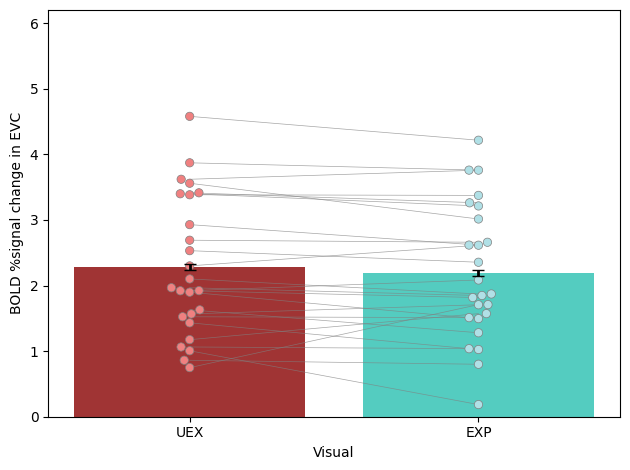

In [47]:
x = "v_pred"
y = "mean"
barplot_morey_maineffect(df[df["attended_modality"] == "all"], x, y, ["firebrick", "turquoise"], ["lightcoral", "powderblue"], barplot_plot=True, swarmplot_plot=True, within_lines=True)
plt.ylabel(f"BOLD %signal change in {ROI}")
plt.xlabel(f"{MOD_PRED}")
plt.xticks([0, 1], ["UEX", "EXP"])
plt.ylim(0, 6.2)
plt.tight_layout()
plt.savefig(f"figures/ROI/{ROI}_allruns.svg", dpi=300)
plt.show()

/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

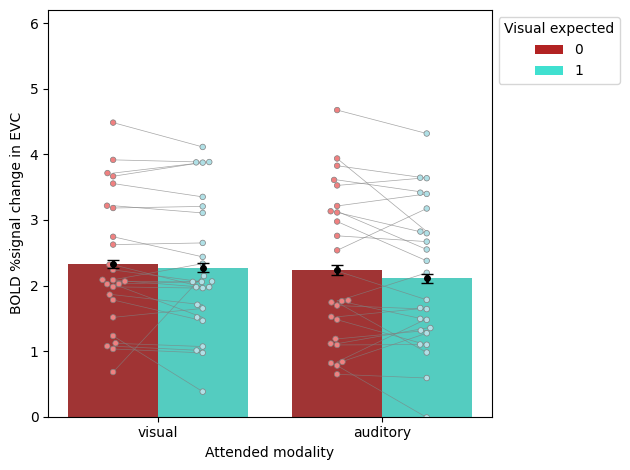

                       Source        SS  ddof1  ddof2        MS         F  \
0           attended_modality  0.400668      1     24  0.400668  2.341465   
1                      v_pred  0.212529      1     24  0.212529  1.779317   
2  attended_modality * v_pred  0.034328      1     24  0.034328  0.568118   

      p-unc  p-GG-corr       ng2  eps  
0  0.139046   0.139046  0.003602  1.0  
1  0.194754   0.194754  0.001914  1.0  
2  0.458339   0.458339  0.000310  1.0  


/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Contrast,attended_modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,attended_modality,-,auditory,visual,True,True,-1.530185,24.0,two-sided,0.139046,NaN,NaN,0.589,-0.118303
1,v_pred,-,0,1,True,True,1.333910,24.0,two-sided,0.194754,NaN,NaN,0.464,0.086667
2,attended_modality * v_pred,auditory,0,1,True,True,1.437841,24.0,two-sided,0.163391,0.326783,fdr_bh,0.525,0.112245
3,attended_modality * v_pred,visual,0,1,True,True,0.694332,24.0,two-sided,0.494141,0.494141,fdr_bh,0.263,0.053639


In [48]:
x = "attended_modality"
y = "mean"
hue = "v_pred"
dat = df[df["attended_modality"] != "all"]
barplot_morey(dat, x, y, hue, "Visual expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], barplot_plot=True, swarmplot_plot=True, within_lines=True)
plt.ylabel(f"BOLD %signal change in {ROI}")
plt.xlabel("Attended modality")
plt.ylim(0, 6.2)
plt.tight_layout()
plt.savefig(f"figures/ROI/{ROI}_attention.svg", dpi=300)

plt.show()
print(pg.rm_anova(dv=y, within=[x, hue], subject='subj', data=dat))
pg.pairwise_tests(dv=y, within=[x, hue], subject='subj', data=dat, padjust='fdr_bh')

In [10]:
pg.pairwise_tests(dv=y, within=[x, hue], subject='subj', data=df[df[x] != "all"], padjust='fdr_bh')

,Contrast,attended_modality,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,attended_modality,-,auditory,visual,True,True,-1.530185,24.0,two-sided,0.139046,NaN,NaN,0.589,-0.118303
1,v_pred,-,0,1,True,True,1.333910,24.0,two-sided,0.194754,NaN,NaN,0.464,0.086667
2,attended_modality * v_pred,auditory,0,1,True,True,1.437841,24.0,two-sided,0.163391,0.326783,fdr_bh,0.525,0.112245
3,attended_modality * v_pred,visual,0,1,True,True,0.694332,24.0,two-sided,0.494141,0.494141,fdr_bh,0.263,0.053639


### visual * auditory prediction

In [49]:
crossmodal_df = []
for subj in SUBJLIST:
    # Load the mask
    mask_path = f"{DATA_PATH}/derivatives/masks/{subj}/{ROI}/MNI_space/{subj}_{ROI}.nii.gz"
    mask = nib.load(mask_path).get_fdata()

    for i, attended_modality in enumerate(["all", "visual", "auditory"]):
        runs_contrast = str(i+1)
                    
        for a_pred in [0, 1]:
            for v_pred in [0, 1]:
                if (a_pred == 1) and (v_pred == 1): 
                    cope_path = f"{DATA_PATH}/derivatives/fsl_secondlevel/{subj}/{subj}_task-main.gfeat/cope1.feat/stats/cope{runs_contrast}.nii.gz"
                elif (a_pred == 1) and (v_pred == 0):
                    cope_path = f"{DATA_PATH}/derivatives/fsl_secondlevel/{subj}/{subj}_task-main.gfeat/cope2.feat/stats/cope{runs_contrast}.nii.gz"
                elif (a_pred == 0) and (v_pred == 1):
                    cope_path = f"{DATA_PATH}/derivatives/fsl_secondlevel/{subj}/{subj}_task-main.gfeat/cope3.feat/stats/cope{runs_contrast}.nii.gz"
                elif (a_pred == 0) and (v_pred == 0):
                    cope_path = f"{DATA_PATH}/derivatives/fsl_secondlevel/{subj}/{subj}_task-main.gfeat/cope4.feat/stats/cope{runs_contrast}.nii.gz"

                # Load the cope
                cope = nib.load(cope_path).get_fdata()/100
                # Get the mean of the cope within the mask
                mean_ROI = np.mean(cope[mask>0])
                std_ROI = np.std(cope[mask>0])

                crossmodal_df.append({"subj":subj, "a_pred":a_pred, "v_pred":v_pred, "attended_modality":attended_modality, "mean":mean_ROI, "std":std_ROI})

multimodal_df = pd.DataFrame(crossmodal_df)

/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:88: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['subject_mean'] = dat.groupby('subj')[y].transform('mean')
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:89: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat['cousineau_normalized'] = dat[y] - dat['subject_mean']
/media/wiseman/tocho/multipred-fmri/multipred/plotting.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_i

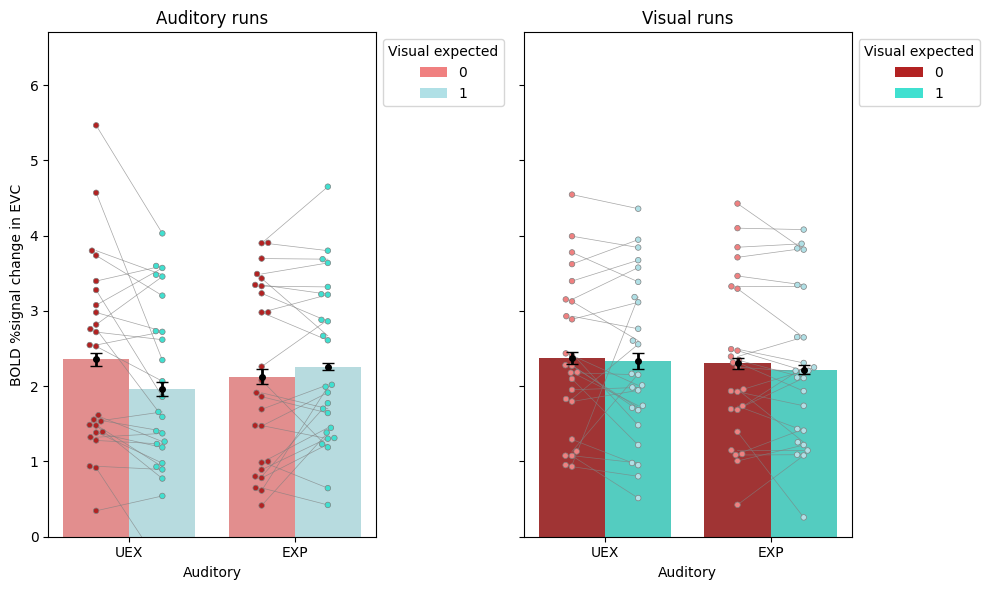

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
x = "a_pred"
y = "mean"
hue = "v_pred"

barplot_morey(multimodal_df[multimodal_df["attended_modality"] == "auditory"], x, y, hue, "Visual expected", ["lightcoral", "powderblue"], ["firebrick", "turquoise"], barplot_plot=True, swarmplot_plot=True, within_lines=True, ax=axes[0])
axes[0].set_title("Auditory runs")
axes[0].set_ylabel(f"BOLD %signal change in {ROI}")
axes[0].set_xlabel("Auditory")
axes[0].set_xticklabels(["UEX", "EXP"])
axes[0].set_ylim(0, 6.7)

barplot_morey(multimodal_df[multimodal_df["attended_modality"] == "visual"], x, y, hue, "Visual expected", ["firebrick", "turquoise"], ["lightcoral", "powderblue"], barplot_plot=True, swarmplot_plot=True, within_lines=True, ax=axes[1])
axes[1].set_title("Visual runs")
axes[1].set_xlabel("Auditory")
axes[1].set_xticklabels(["UEX", "EXP"])

plt.tight_layout()
plt.savefig(f"figures/ROI/{ROI}_interaction.svg", dpi=300)

In [51]:
AnovaRM(multimodal_df[multimodal_df["attended_modality"] != "all"], y, subject='subj', within=[x, hue, "attended_modality"]).fit().summary()

,F Value,Num DF,Den DF,Pr > F
a_pred,0.2104,1.0000,24.0000,0.6506
v_pred,1.8763,1.0000,24.0000,0.1834
attended_modality,2.4634,1.0000,24.0000,0.1296
a_pred:v_pred,6.1466,1.0000,24.0000,0.0206
a_pred:attended_modality,1.3184,1.0000,24.0000,0.2622
v_pred:attended_modality,0.4842,1.0000,24.0000,0.4932
a_pred:v_pred:attended_modality,4.9710,1.0000,24.0000,0.0354


In [32]:
print("Anova auditory runs")
pg.rm_anova(dv=y, within=[x, hue], subject='subj', data=multimodal_df[multimodal_df["attended_modality"] == "auditory"])

Anova auditory runs


/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,a_pred,0.029035,1,24,0.029035,0.150172,0.701787,0.701787,0.000219,1.0
1,v_pred,0.417512,1,24,0.417512,2.051058,0.164997,0.164997,0.003139,1.0
2,a_pred * v_pred,1.736171,1,24,1.736171,9.947231,0.004293,0.004293,0.012924,1.0


In [33]:
print("Anova visual runs")
pg.rm_anova(dv=y, within=[x, hue], subject='subj', data=multimodal_df[multimodal_df["attended_modality"] == "visual"])

Anova visual runs


/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/media/wiseman/tocho/multipred-fmri/.venv/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,a_pred,0.211736,1,24,0.211736,1.349226,0.256836,0.256836,0.002002,1.0
1,v_pred,0.089436,1,24,0.089436,0.562714,0.460460,0.460460,0.000847,1.0
2,a_pred * v_pred,0.010637,1,24,0.010637,0.071634,0.791259,0.791259,0.000101,1.0


In [34]:
print("Pairwise auditory runs")
pg.pairwise_tests(dv=y, within=[x, hue], subject='subj', data=multimodal_df[multimodal_df["attended_modality"] == "auditory"], padjust='fdr_bh')

Pairwise auditory runs


,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,a_pred,-,0,1,True,True,-0.387520,24.0,two-sided,0.701787,NaN,NaN,0.226,-0.029571
1,v_pred,-,0,1,True,True,1.432152,24.0,two-sided,0.164997,NaN,NaN,0.521,0.112024
2,a_pred * v_pred,0,0,1,True,True,2.912383,24.0,two-sided,0.007635,0.015269,fdr_bh,6.002,0.320639
3,a_pred * v_pred,1,0,1,True,True,-1.222852,24.0,two-sided,0.233258,0.233258,fdr_bh,0.411,-0.115543


In [35]:
print("Pairwise visual runs")
pg.pairwise_tests(dv=y, within=[x, hue], subject='subj', data=multimodal_df[multimodal_df["attended_modality"] == "visual"], padjust='fdr_bh')

Pairwise visual runs


,Contrast,a_pred,A,B,Paired,Parametric,T,dof,alternative,p-unc,p-corr,p-adjust,BF10,hedges
0,a_pred,-,0,1,True,True,1.161562,24.0,two-sided,0.256836,NaN,NaN,0.385,0.089577
1,v_pred,-,0,1,True,True,0.750142,24.0,two-sided,0.460460,NaN,NaN,0.272,0.058204
2,a_pred * v_pred,0,0,1,True,True,0.294202,24.0,two-sided,0.771133,0.771133,fdr_bh,0.219,0.036760
3,a_pred * v_pred,1,0,1,True,True,0.971611,24.0,two-sided,0.340935,0.681870,fdr_bh,0.323,0.075558
